In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv('Telco_Customer_Churn_CLEANED.csv')
df.shape 
df.info
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.isnull().sum()
df.duplicated().sum()
df.dtypes


customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [6]:
#overall churn rate
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [7]:
#Univariate analysis
df['tenure'].describe()
df['MonthlyCharges'].describe()
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
#Bivariate analysis Vs Churn
pd.crosstab(df['Churn'],df['Contract'], normalize='index') * 100
pd.crosstab(df['Churn'],df['InternetService'], normalize='index') * 100
df.groupby('Churn')['tenure'].describe()
df.groupby('Churn')['MonthlyCharges'].describe()
df.groupby('Churn')['TotalCharges'].describe()
pd.crosstab(df['Churn'],df['gender'], normalize='index') * 100
pd.crosstab(df['Churn'],df['SeniorCitizen'], normalize='index') * 100
pd.crosstab(df['Churn'],df['Partner'], normalize='index') * 100
pd.crosstab(df['Churn'],df['Dependents'], normalize='index') * 100
pd.crosstab(df['Churn'],df['PhoneService'], normalize='index') * 100
pd.crosstab(df['Churn'],df['MultipleLines'], normalize='index') * 100
pd.crosstab(df['Churn'],df['OnlineSecurity'], normalize='index') * 100
pd.crosstab(df['Churn'],df['OnlineBackup'], normalize='index') * 100
pd.crosstab(df['Churn'],df['DeviceProtection'], normalize='index') * 100
pd.crosstab(df['Churn'],df['TechSupport'], normalize='index') * 100
pd.crosstab(df['Churn'],df['StreamingTV'], normalize='index') * 100
pd.crosstab(df['Churn'],df['StreamingMovies'], normalize='index') * 100
pd.crosstab(df['Churn'],df['PaperlessBilling'], normalize='index') * 100
pd.crosstab(df['Churn'],df['PaymentMethod'], normalize='index') * 100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,24.855044,24.932354,25.009664,25.202938
Yes,13.804173,12.413055,57.303371,16.479401


In [12]:
#Correlation between numerixc variables
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


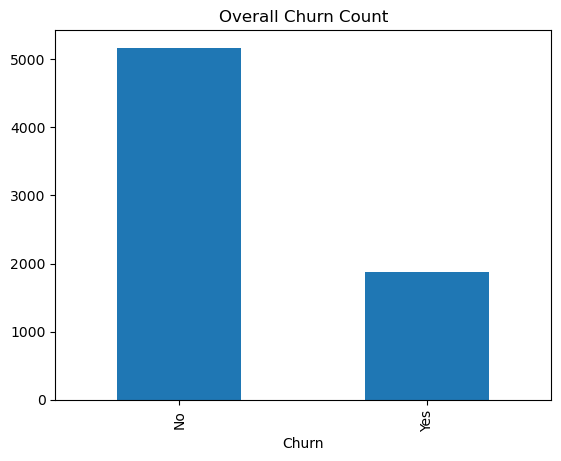

In [17]:
# OVERALL CHURN COUNT
df['Churn'].value_counts().plot(kind= 'bar')
plt.title('Overall Churn Count')
plt.show()

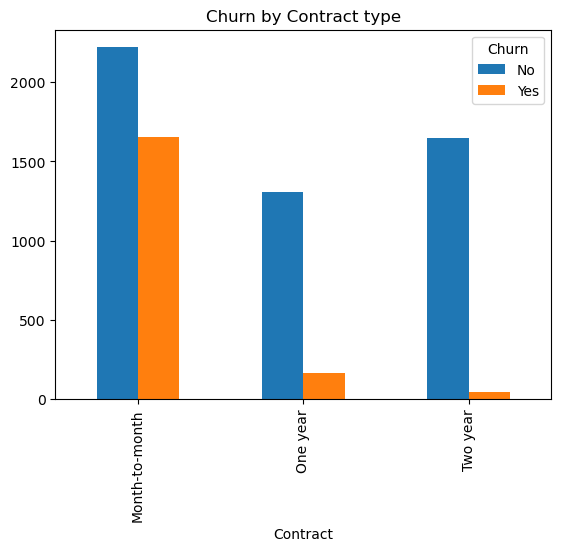

In [18]:
# Churn by Contract
pd.crosstab(df['Contract'],df['Churn']).plot(kind= 'bar')
plt.title('Churn by Contract type')
plt.show()


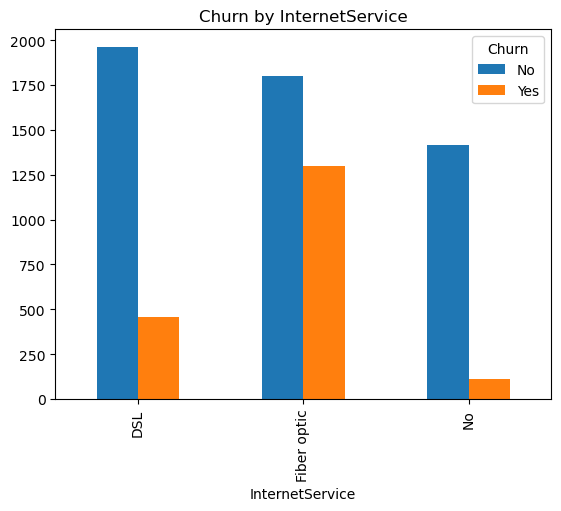

In [20]:
# Churn by Internet Services
pd.crosstab(df['InternetService'],df['Churn']).plot(kind= 'bar')
plt.title('Churn by InternetService')
plt.show()


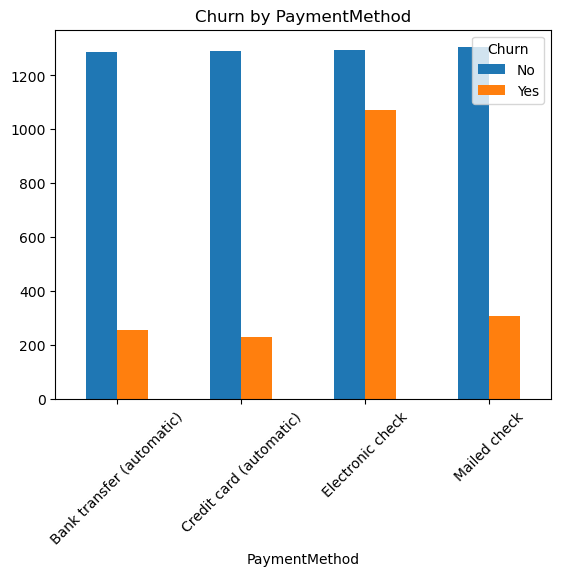

In [21]:
# Churn by Contract
pd.crosstab(df['PaymentMethod'],df['Churn']).plot(kind= 'bar')
plt.title('Churn by PaymentMethod')
plt.xticks(rotation=45)
plt.show()


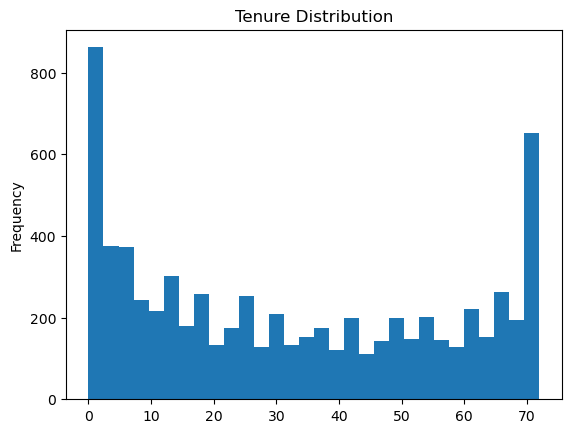

In [22]:
# Tenure Distribution
df['tenure'].plot(kind='hist', bins=30)
plt.title('Tenure Distribution')
plt.show()

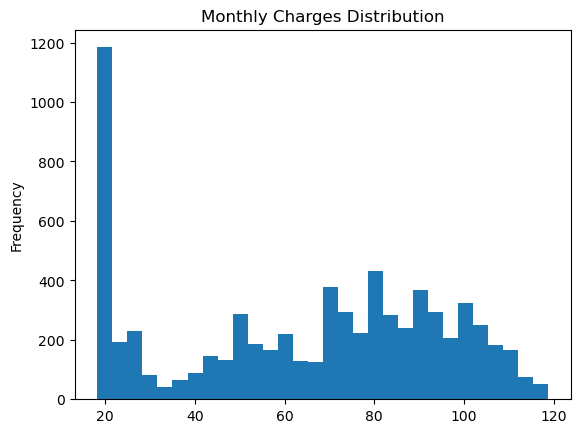

In [23]:
# Monthly Charges distribution
df['MonthlyCharges'].plot(kind='hist', bins=30)
plt.title('Monthly Charges Distribution')
plt.show()

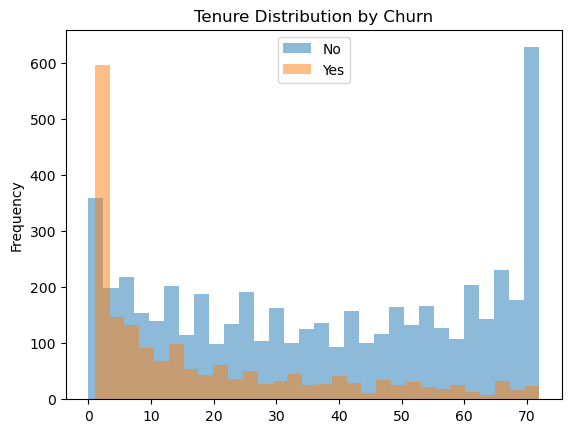

In [24]:
# Tenure distribution by Churn
df.groupby('Churn')['tenure'].plot(kind='hist', bins=30, alpha=0.5, legend=True)
plt.title('Tenure Distribution by Churn')
plt.show()
